In [7]:
import os
import pandas as pd
import numpy as np

ROOT_DIR = os.path.dirname(os.getcwd()) 

df = pd.read_csv(os.path.join(ROOT_DIR, "results", "admet_results.csv")) 

# rank within each task
def get_rank_direction(metric):
    # ROC_AUC, PR_AUC, Spearman: higher is better; MAE: lower is better
    if any(m in metric for m in ["ROC_AUC", "PR_AUC", "Spearman"]):
        return False # ascending=False, larger is better
    else:
        return True # ascending=True, smaller is better

df["rank"] = np.nan

for (task_group, data_name, metric), sub in df.groupby(["task_group", "data_name", "metric"]):
    # decide sorting direction based on the metric
    asc = get_rank_direction(metric)
    # sort and assign ranks
    idx = sub.sort_values("mean", ascending=asc).index
    df.loc[idx, "rank"] = np.arange(1, len(idx) + 1)

print(df.head())


   task_group data_name   metric   model   mean    std  rank
0  Absorption     Caco2      MAE  D-MPNN  0.377  0.030   3.0
1  Absorption       HIA  ROC_AUC  D-MPNN  0.964  0.020   5.0
2  Absorption       Pgp  ROC_AUC  D-MPNN  0.905  0.021   2.0
3  Absorption     Bioav  ROC_AUC  D-MPNN  0.644  0.037   6.0
4  Absorption      Lipo      MAE  D-MPNN  0.402  0.012   1.0


In [8]:
# Mean
group_rank_mean_df = (
    df.groupby(["task_group", "model"])["rank"]
    .mean()
    .unstack()
)
print(group_rank_mean_df)


# Median
group_rank_median_df = (
    df.groupby(["task_group", "model"])["rank"]
    .median()
    .unstack()
)
print(group_rank_median_df)


model           D-MPNN  D-MPNN+Desc  D-MPNN+MMB  D-MPNN+MMB+Desc      Desc  \
task_group                                                                   
Absorption    3.333333     2.500000    5.500000         2.500000  4.000000   
Distribution  2.333333     5.333333    3.666667         1.000000  4.000000   
Excretion     3.000000     3.333333    2.666667         3.666667  3.333333   
Metabolism    3.333333     4.333333    4.833333         3.000000  4.166667   
Toxicity      4.000000     1.500000    4.250000         3.750000  3.000000   

model              GCN  GCN+MMB+Desc       MMB  
task_group                                      
Absorption    6.833333      4.500000  6.833333  
Distribution  7.666667      4.666667  7.333333  
Excretion     8.000000      5.000000  7.000000  
Metabolism    6.833333      4.000000  5.500000  
Toxicity      6.750000      5.500000  7.250000  
model         D-MPNN  D-MPNN+Desc  D-MPNN+MMB  D-MPNN+MMB+Desc  Desc  GCN  \
task_group                       

# Radar Chart (rank)

## mean

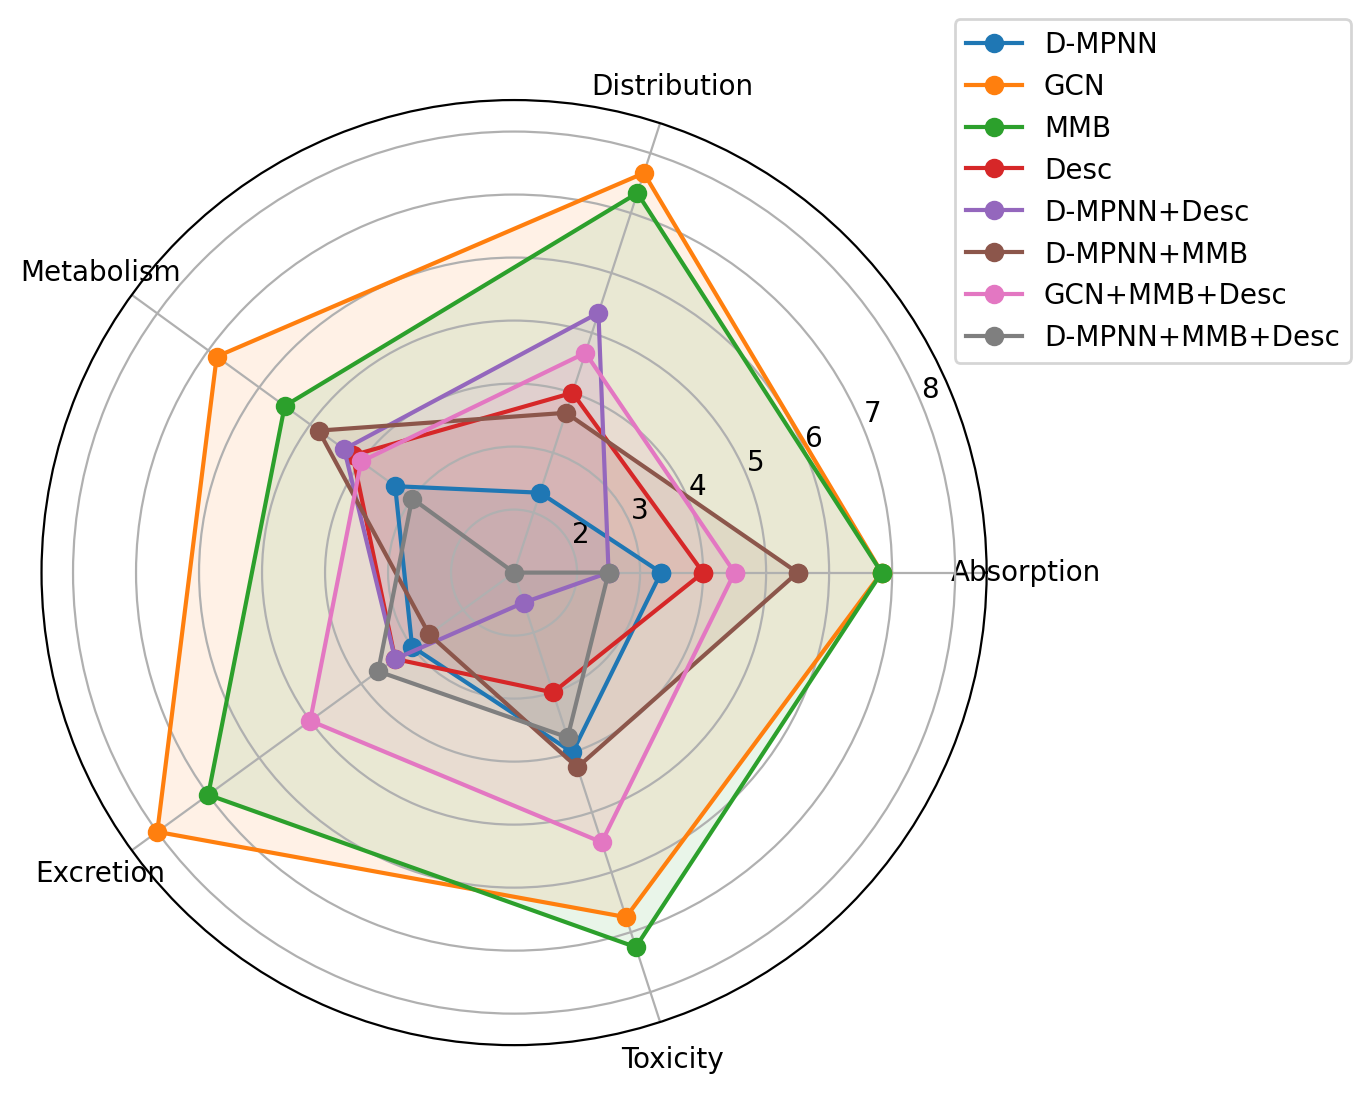

In [9]:
import matplotlib.pyplot as plt
import numpy as np

models = ["D-MPNN", "GCN", "MMB", "Desc", "D-MPNN+Desc", "D-MPNN+MMB", "GCN+MMB+Desc", "D-MPNN+MMB+Desc"]
task_groups = ["Absorption", "Distribution", "Metabolism", "Excretion", "Toxicity"]

group_rank_df = group_rank_mean_df.loc[task_groups, models]

labels = task_groups
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1] 

plt.figure(figsize=(7, 7), dpi=200)
ax = plt.subplot(111, polar=True)

for model in models:
    values = group_rank_df[model].values.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, marker='o')
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(1, group_rank_df.max().max() + 0.5)
# ax.set_title("ADMET Groups Model Rank Radar Chart", size=15)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.show()


## median

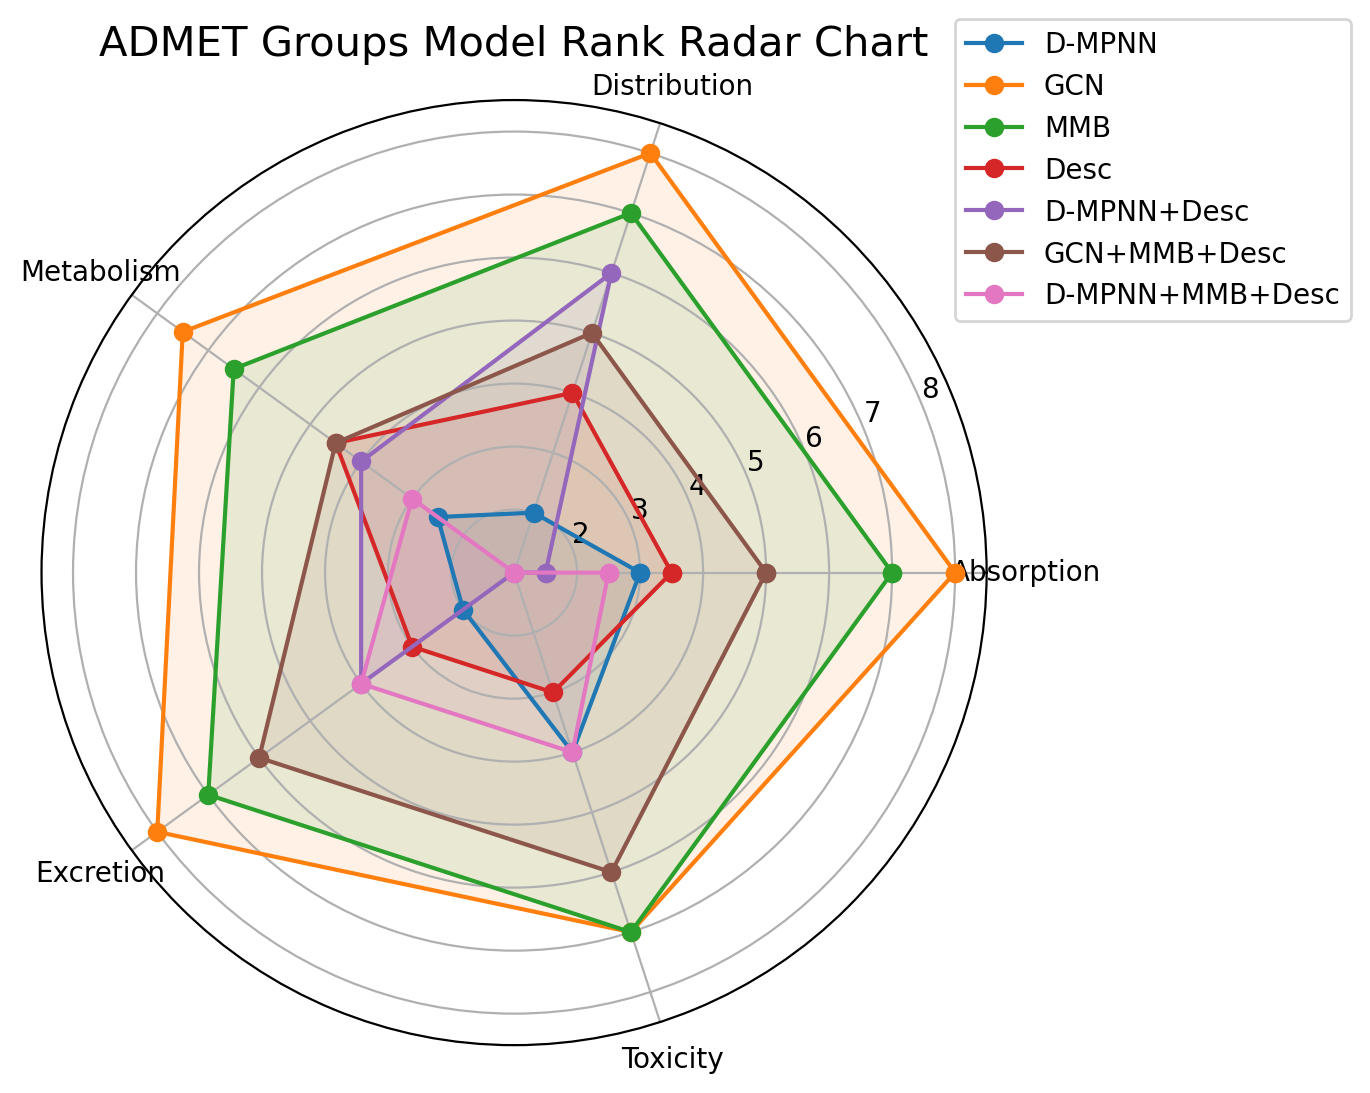

In [10]:
models = ["D-MPNN", "GCN", "MMB", "Desc", "D-MPNN+Desc", "GCN+MMB+Desc", "D-MPNN+MMB+Desc"]
task_groups = ["Absorption", "Distribution", "Metabolism", "Excretion", "Toxicity"]

group_rank_df = group_rank_median_df.loc[task_groups, models]

labels = task_groups
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1] 

plt.figure(figsize=(7, 7), dpi=200)
ax = plt.subplot(111, polar=True)

for model in models:
    values = group_rank_df[model].values.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, marker='o')
    ax.fill(angles, values, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(1, group_rank_df.max().max() + 0.5)
ax.set_title("ADMET Groups Model Rank Radar Chart", size=15)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))
plt.tight_layout()
plt.show()

# Heatmap (rank)

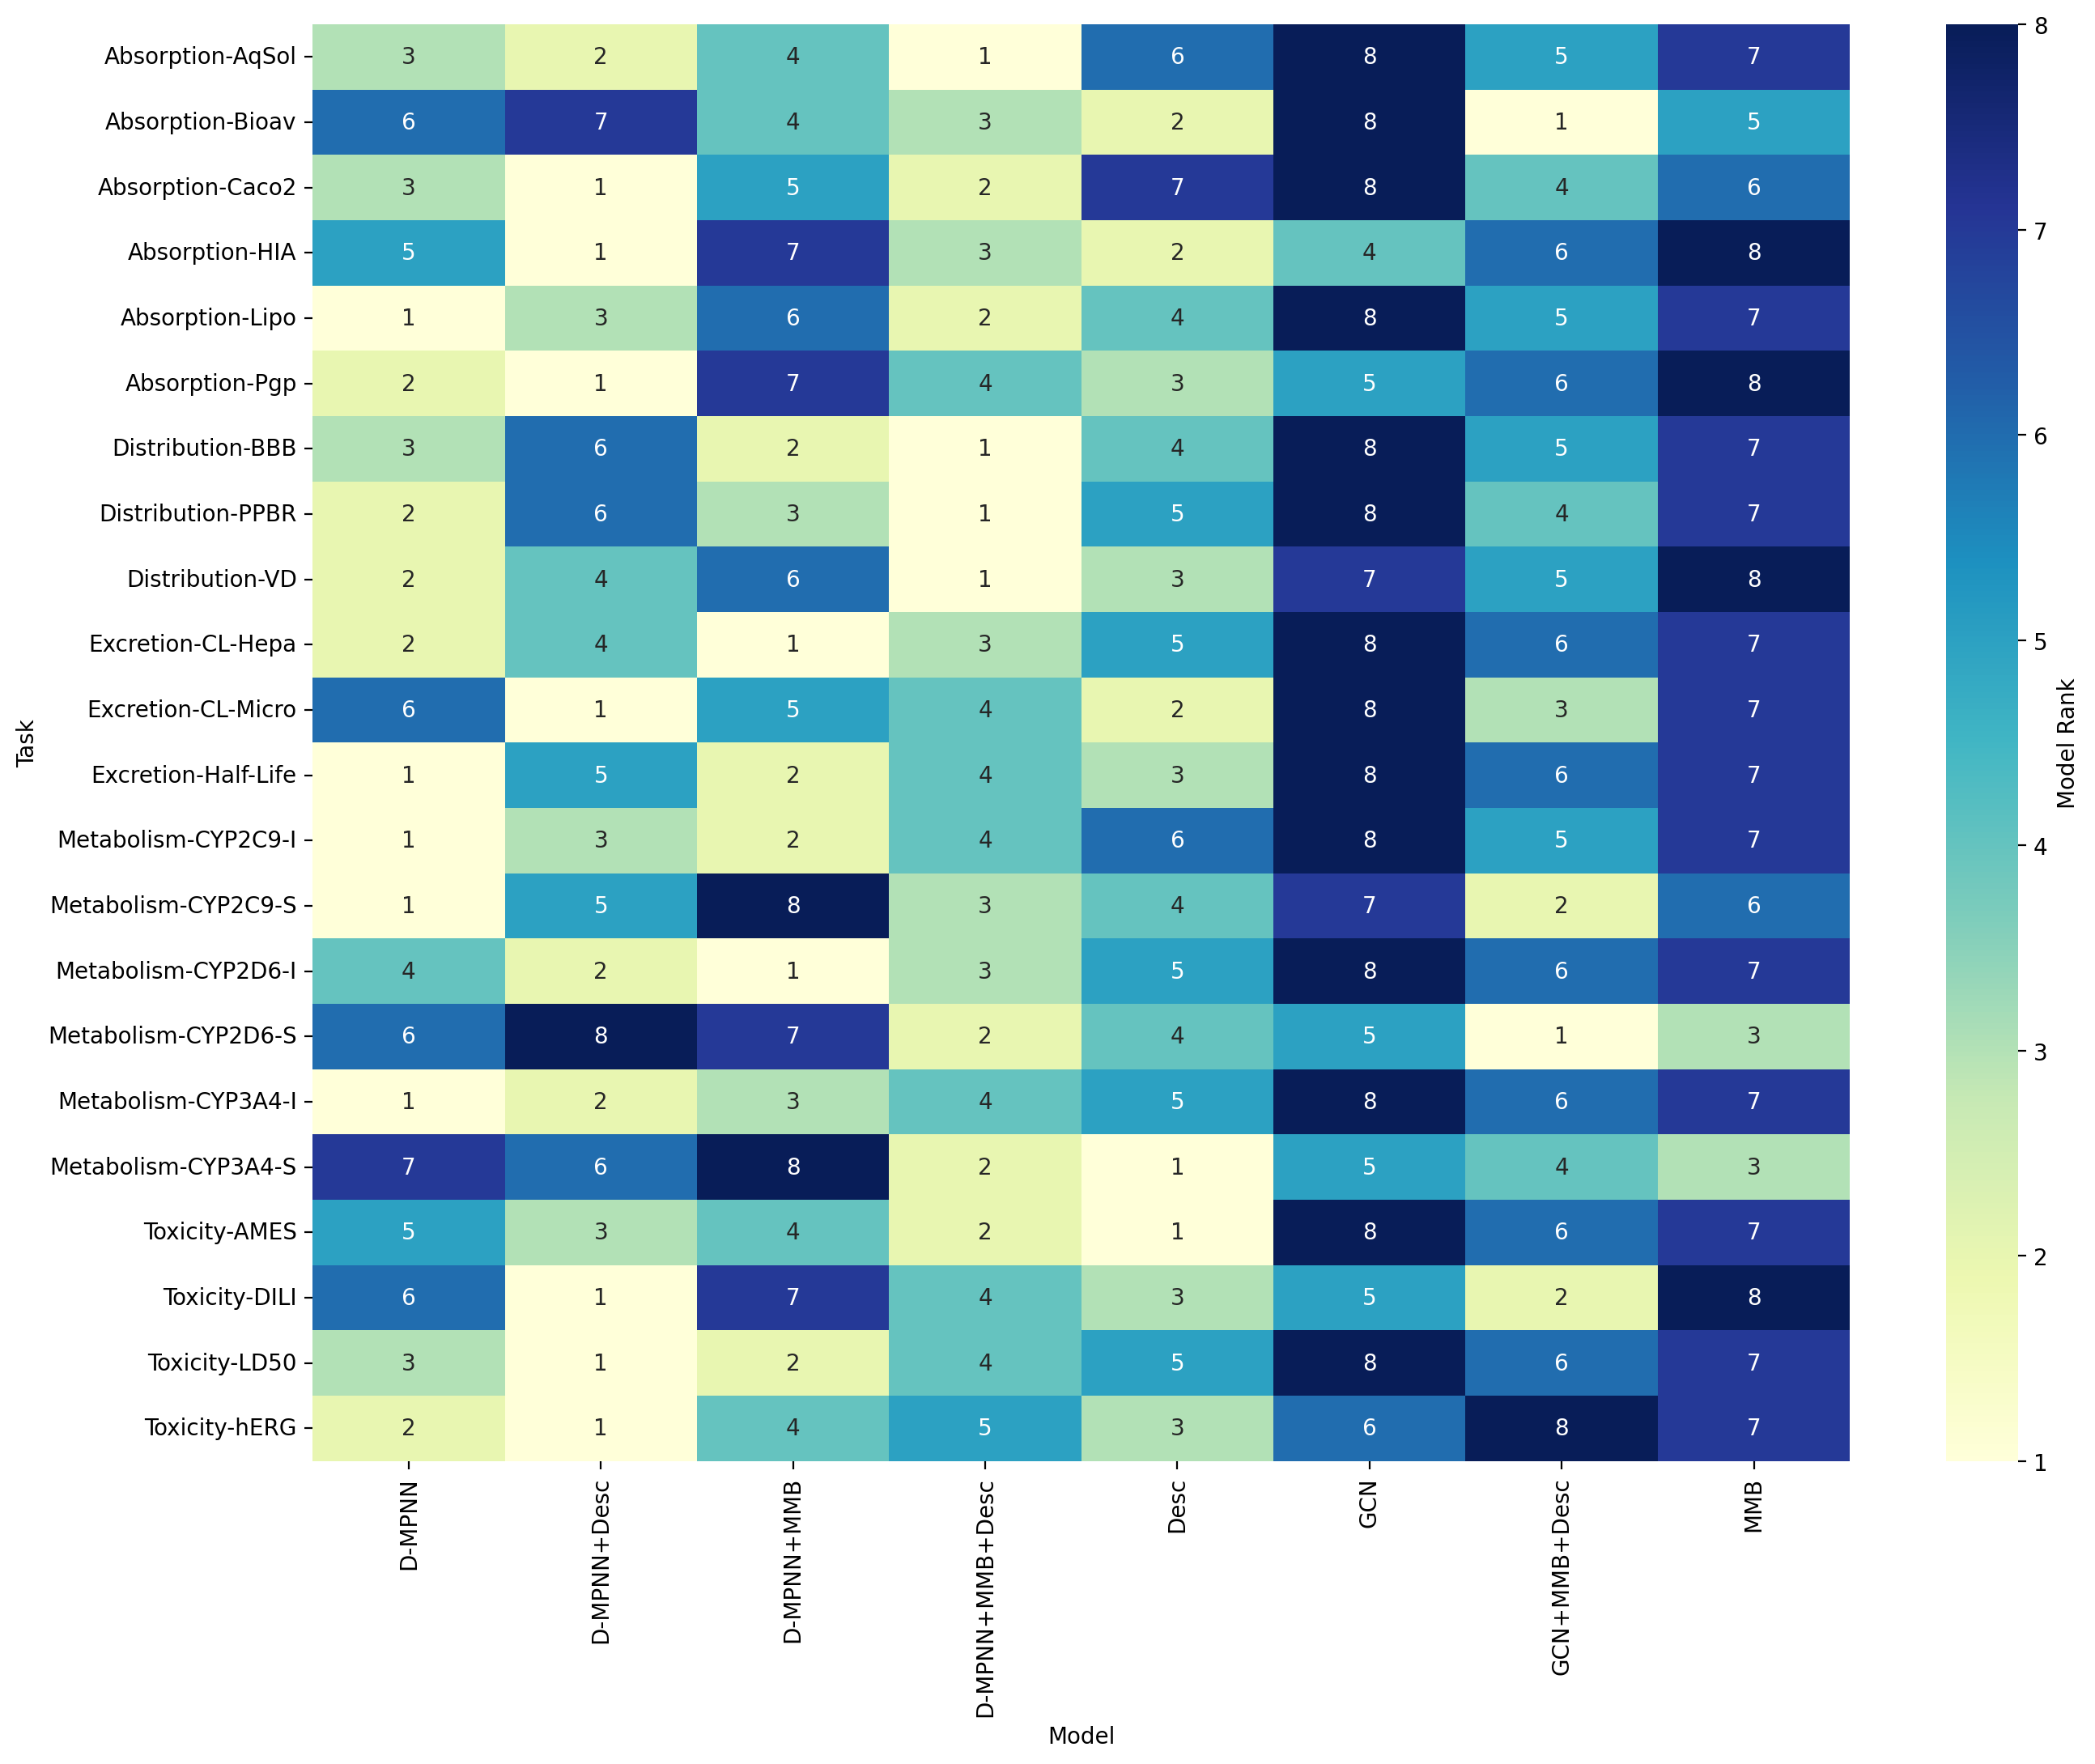

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = (
    # df.pivot_table(index=["task_group", "data_name", "metric"], columns="model", values="rank")
    df.pivot_table(index=["task_group", "data_name"], columns="model", values="rank")
)

plt.figure(figsize=(14, int(len(heatmap_df)/2)), dpi=200)
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Model Rank'})
# plt.title("Model Ranking per Task")
plt.ylabel("Task")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


# Bar chart

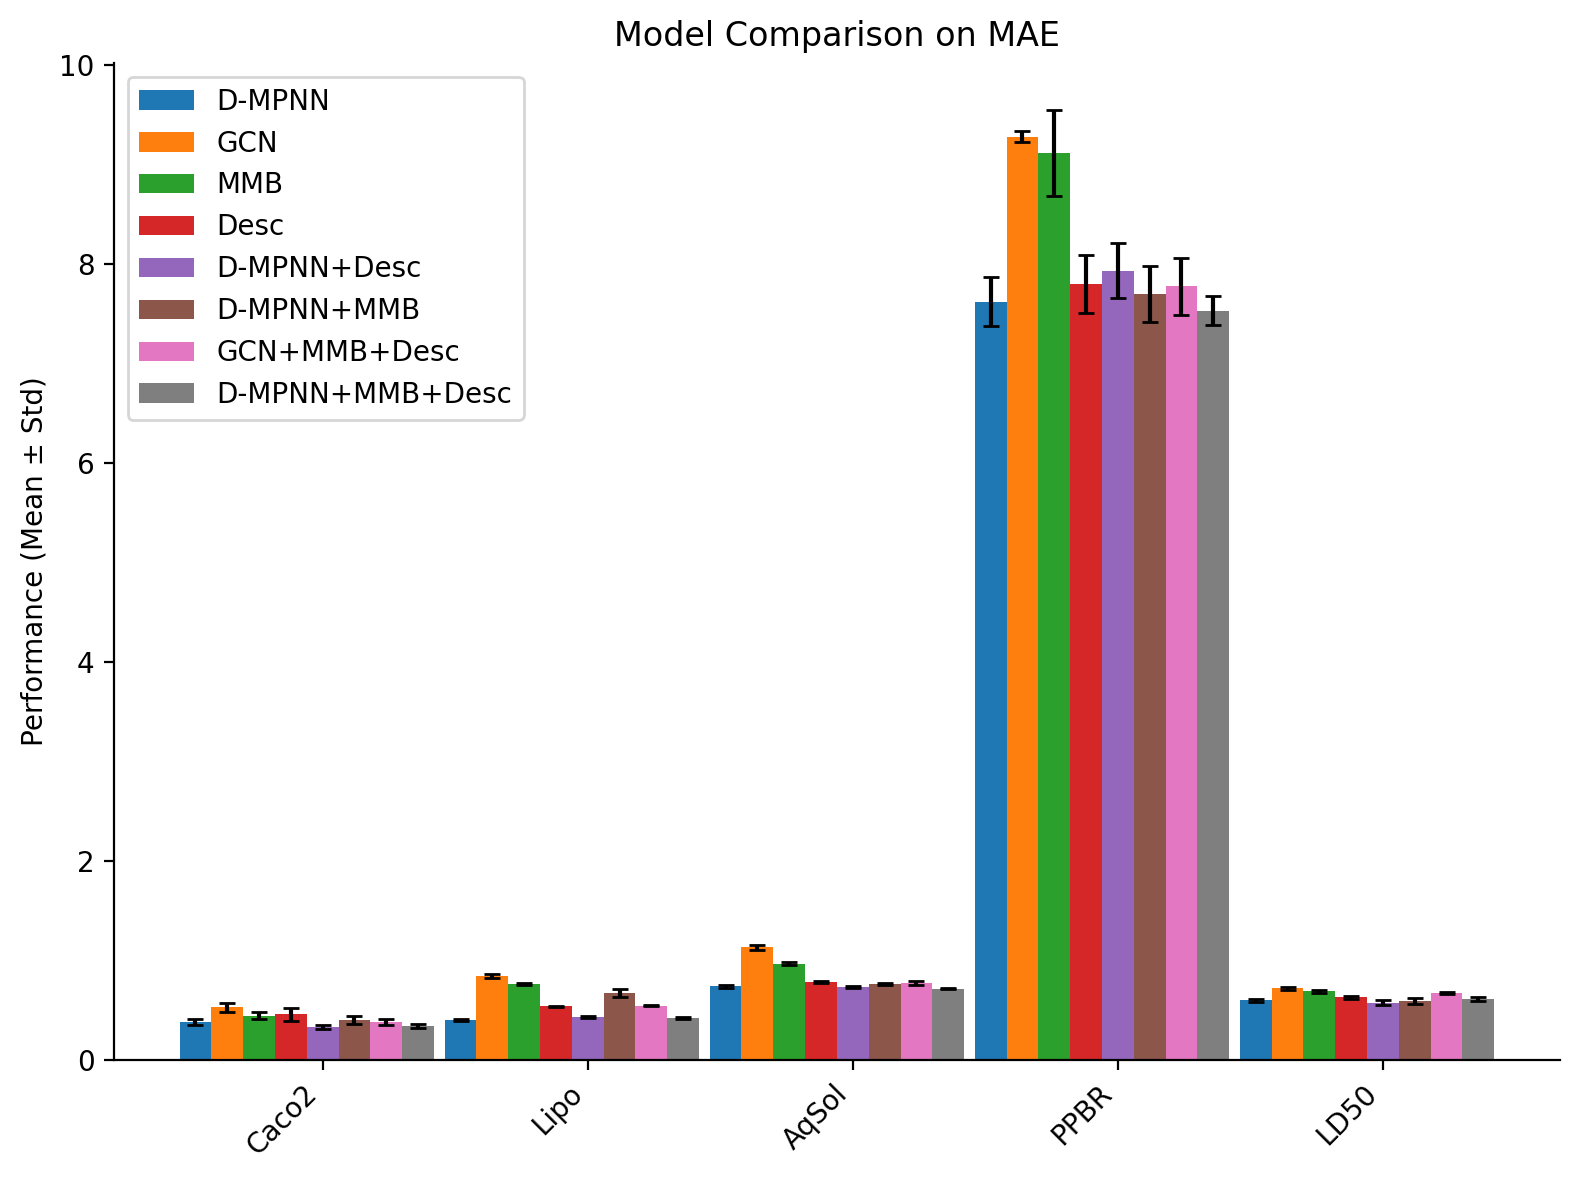

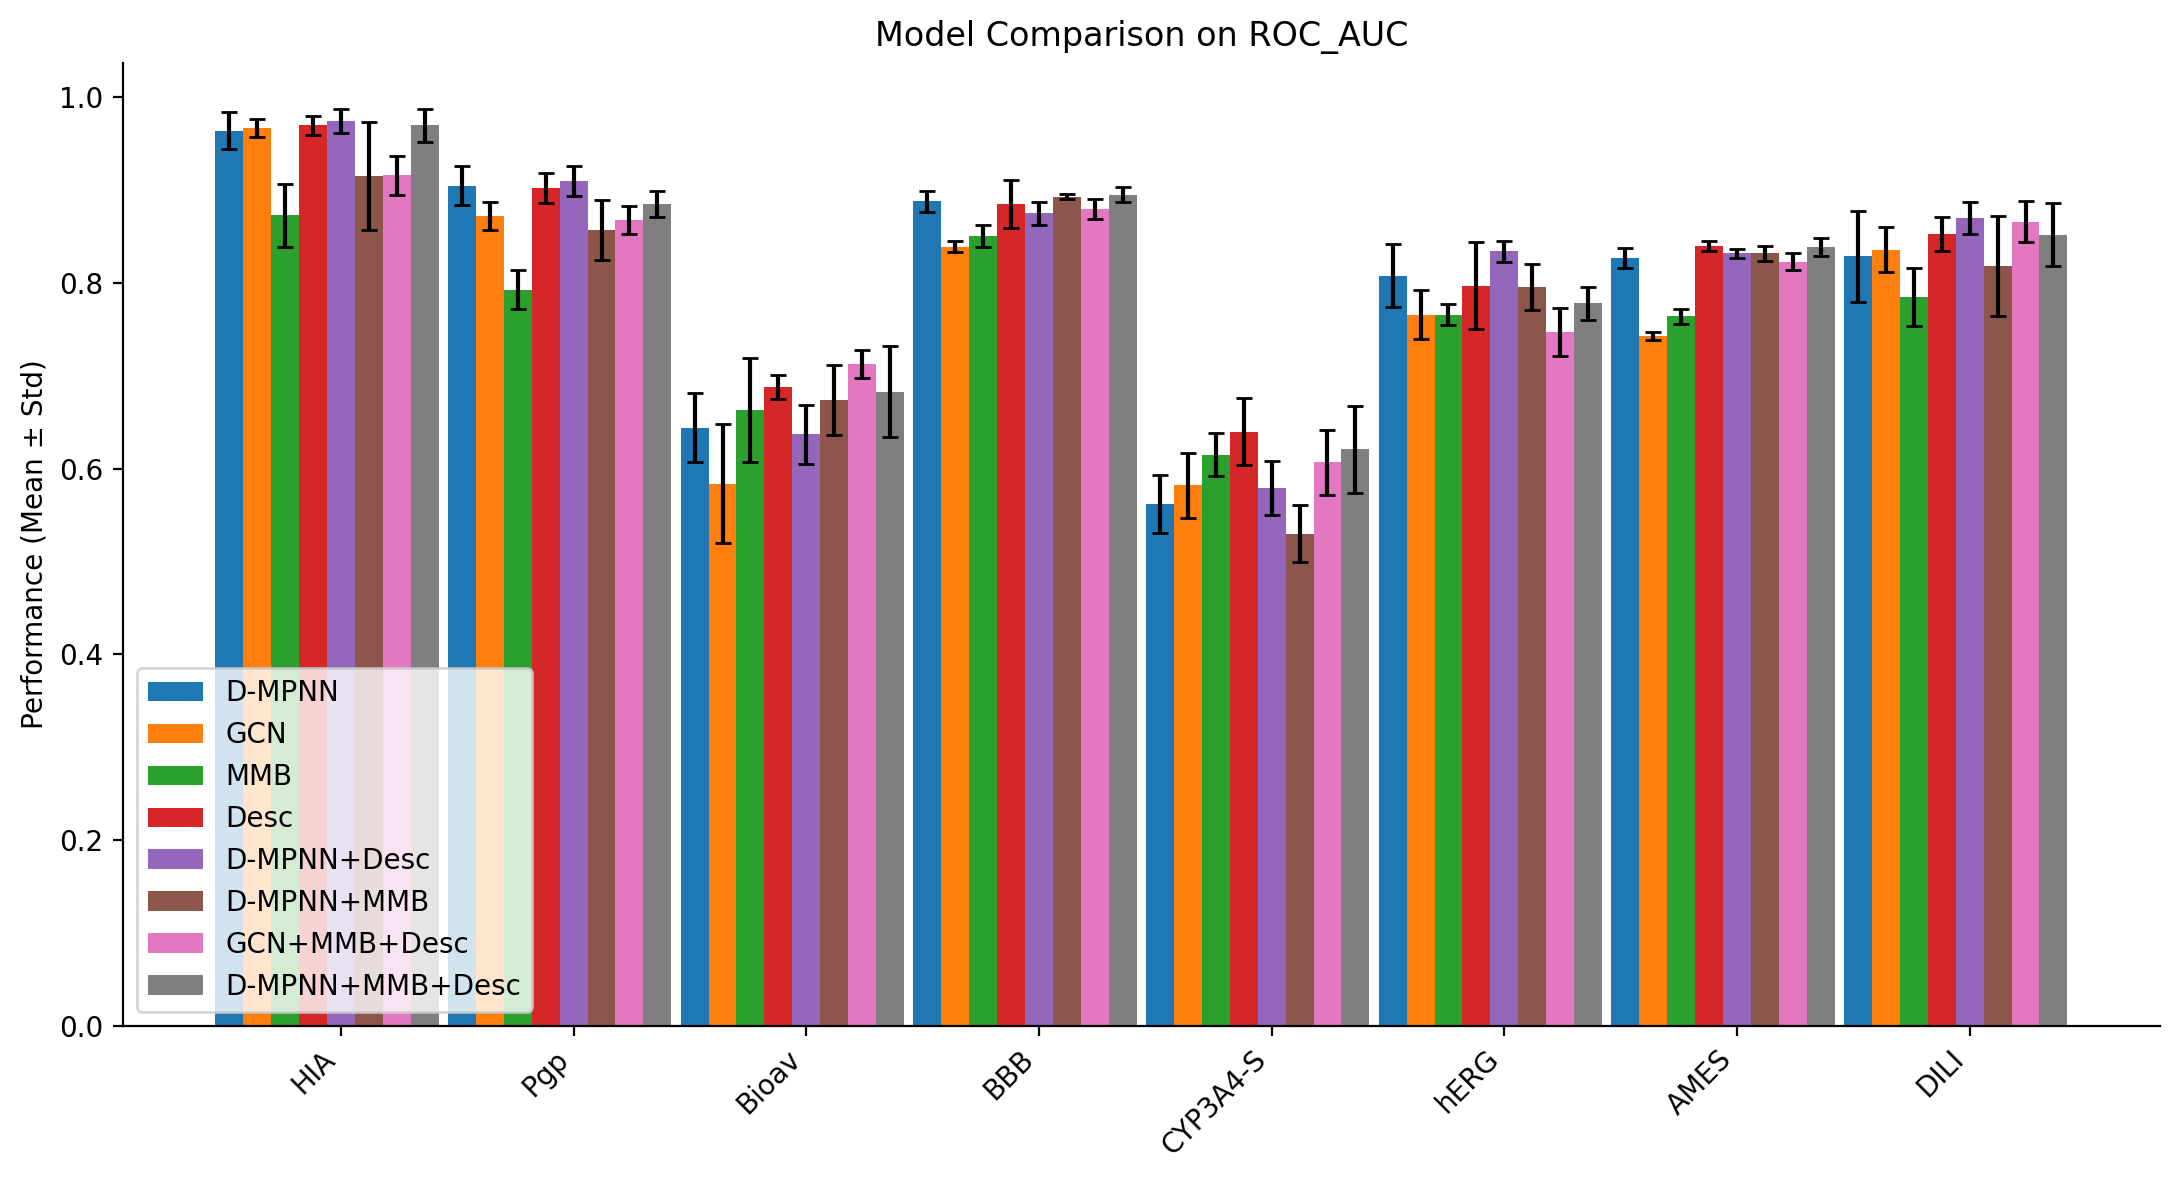

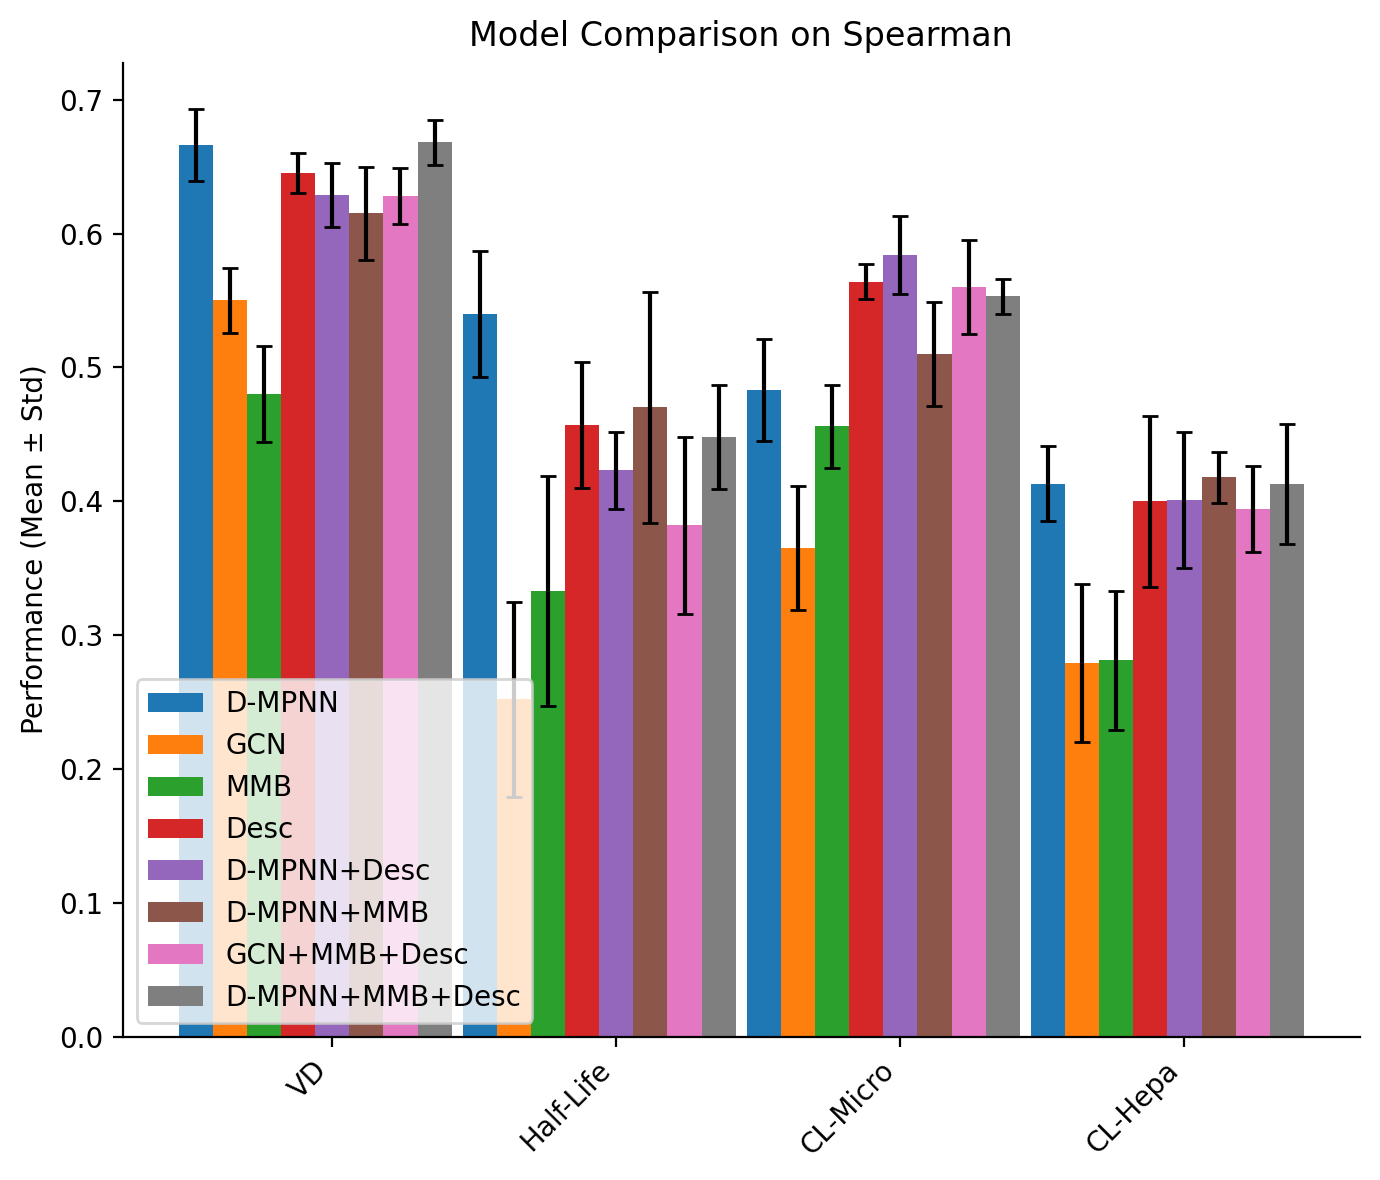

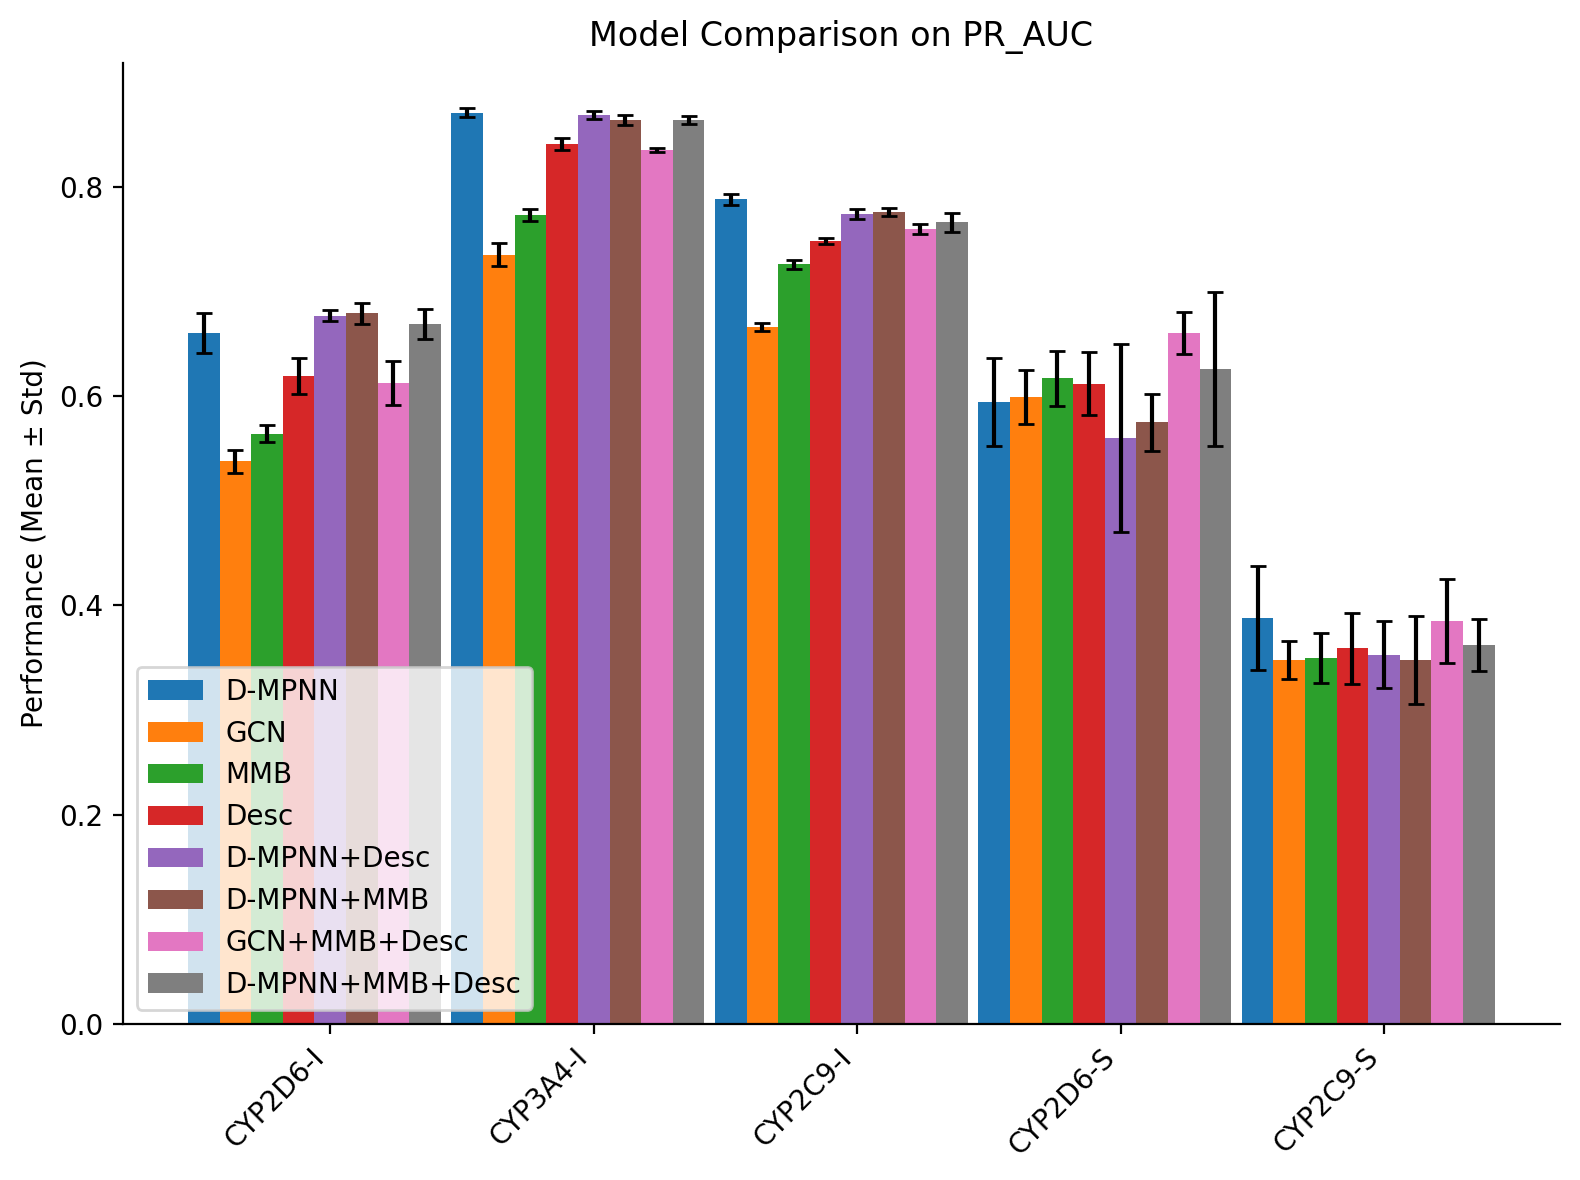

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

metrics = df['metric'].unique()
models = df['model'].unique()

# palette = sns.color_palette("Set2", n_colors=len(models))
# palette = sns.color_palette("Paired", n_colors=len(models))
palette = sns.color_palette("tab10", n_colors=len(models))

for metric in metrics:
    metric_df = df[df['metric'] == metric]
    data_names = metric_df['data_name'].unique()
    x = np.arange(len(data_names))
    width = 0.12

    fig, ax = plt.subplots(figsize=(min(16, 3+len(data_names)), 6), dpi=200)
    for i, model in enumerate(models):
        model_df = metric_df[metric_df['model'] == model].set_index('data_name')
        y = model_df.reindex(data_names)['mean'].values
        yerr = model_df.reindex(data_names)['std'].values
        ax.bar(
            x + i*width,
            y,
            width,
            label=model,
            yerr=yerr,
            capsize=3,
            color=palette[i]
        )

    ax.set_xticks(x + width*len(models)/2)
    ax.set_xticklabels(data_names, rotation=45, ha='right')
    ax.set_ylabel('Performance (Mean ± Std)')
    ax.set_title(f"Model Comparison on {metric}")
    ax.legend()
    sns.despine() 
    plt.tight_layout()
    plt.show()


# Comparison with SMILES-Mamba

In [13]:
import pandas as pd

df = pd.read_csv(os.path.join(ROOT_DIR, "results", "admet_results.csv")) 

mamba_rows = [
    # Absorption
    ("Absorption", "Caco2",     "MAE",      0.438, 0.030),
    ("Absorption", "HIA",       "ROC_AUC",  0.937, 0.011),
    ("Absorption", "Pgp",       "ROC_AUC",  0.930, 0.017),
    ("Absorption", "Bioav",     "ROC_AUC",  0.673, 0.025),
    ("Absorption", "Lipo",      "MAE",      0.583, 0.020),
    ("Absorption", "AqSol",     "MAE",      0.819, 0.020),

    # Distribution
    ("Distribution", "BBB",     "ROC_AUC",  0.852, 0.018),
    ("Distribution", "PPBR",    "MAE",      9.371, 0.311),
    ("Distribution", "VD",      "Spearman", 0.471, 0.099),

    # Metabolism
    ("Metabolism", "CYP2D6-I",  "PR_AUC",   0.747, 0.013),
    ("Metabolism", "CYP3A4-I",  "PR_AUC",   0.893, 0.012),
    ("Metabolism", "CYP2C9-I",  "PR_AUC",   0.845, 0.011),
    ("Metabolism", "CYP2D6-S",  "PR_AUC",   0.748, 0.012),
    ("Metabolism", "CYP3A4-S",  "ROC_AUC",  0.664, 0.027),
    ("Metabolism", "CYP2C9-S",  "PR_AUC",   0.365, 0.021),

    # Excretion
    ("Excretion", "Half-Life",  "Spearman", 0.247, 0.100),
    ("Excretion", "CL-Micro",   "Spearman", 0.501, 0.049),
    ("Excretion", "CL-Hepa",    "Spearman", 0.423, 0.029),

    # Toxicity
    ("Toxicity", "hERG",        "ROC_AUC",  0.708, 0.045),
    ("Toxicity", "AMES",        "ROC_AUC",  0.801, 0.030),
    ("Toxicity", "DILI",        "ROC_AUC",  0.928, 0.022),
    ("Toxicity", "LD50",        "MAE",      0.678, 0.012),
]


mamba_df = pd.DataFrame(mamba_rows, columns=["task_group","data_name","metric","mean","std"])
mamba_df["model"] = "SMILES-Mamba"

df_with_mamba = pd.concat([df, mamba_df], ignore_index=True)


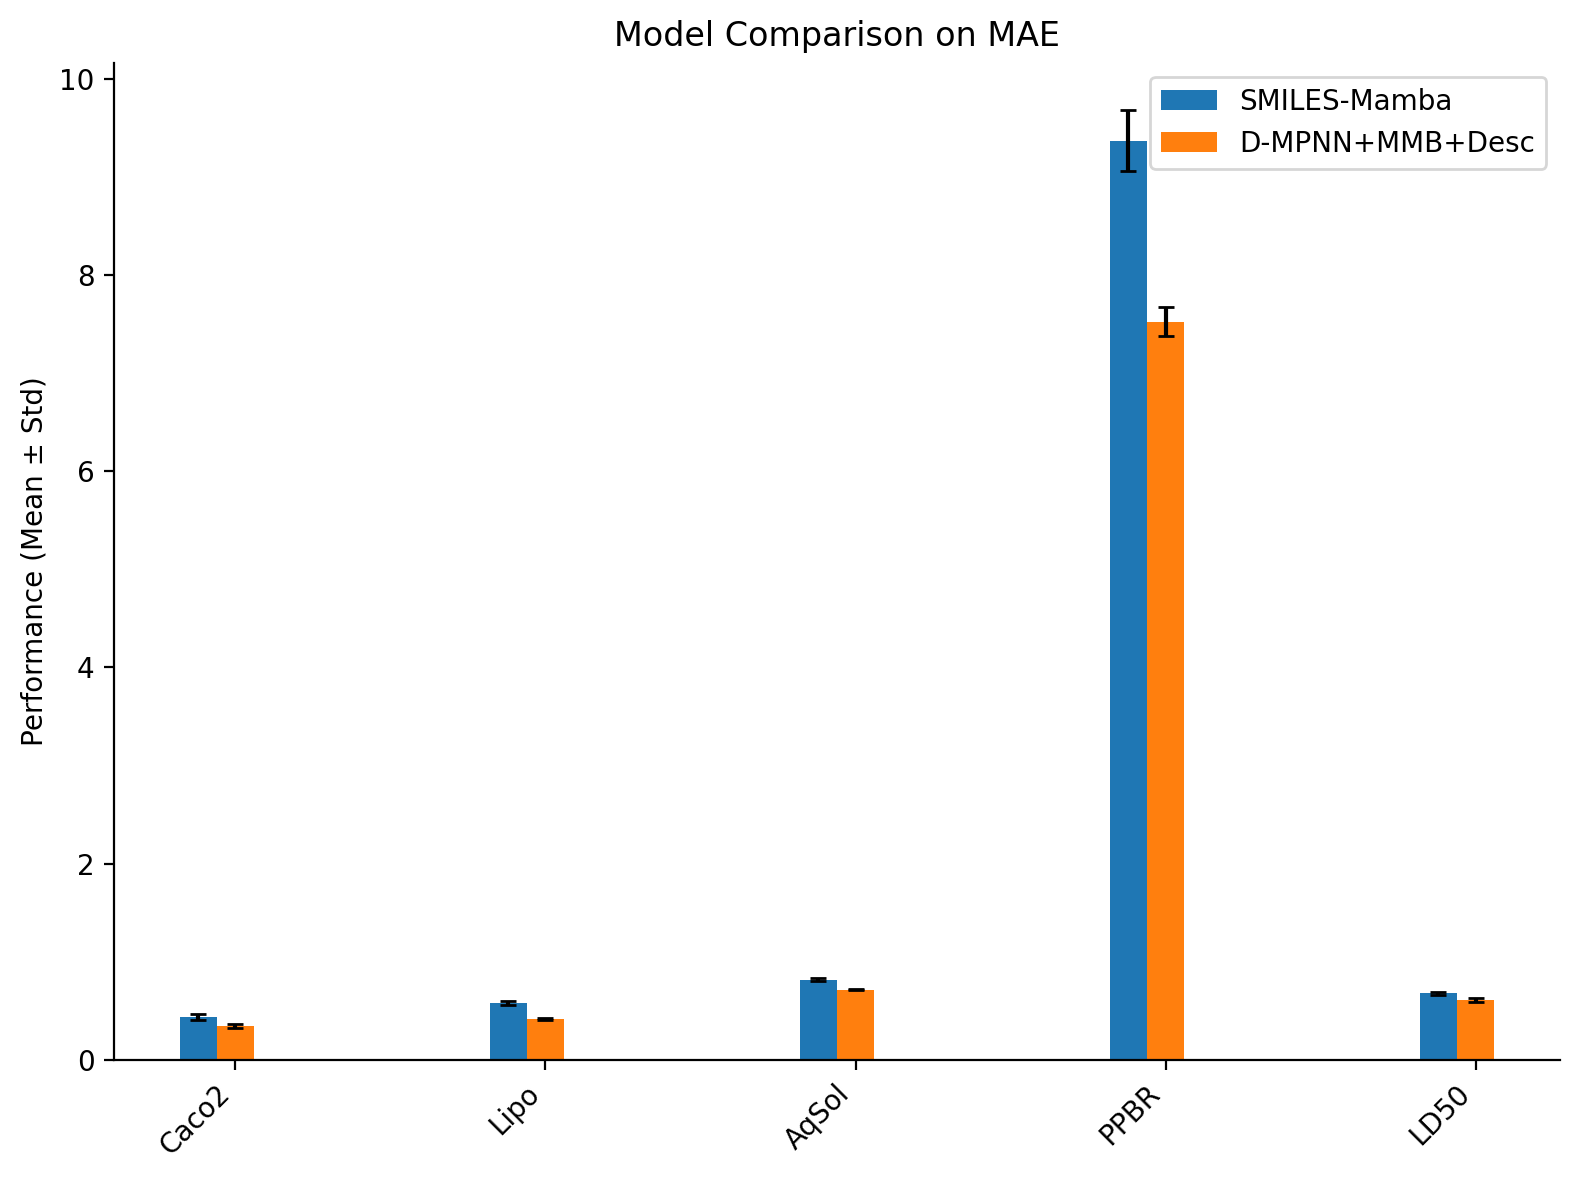

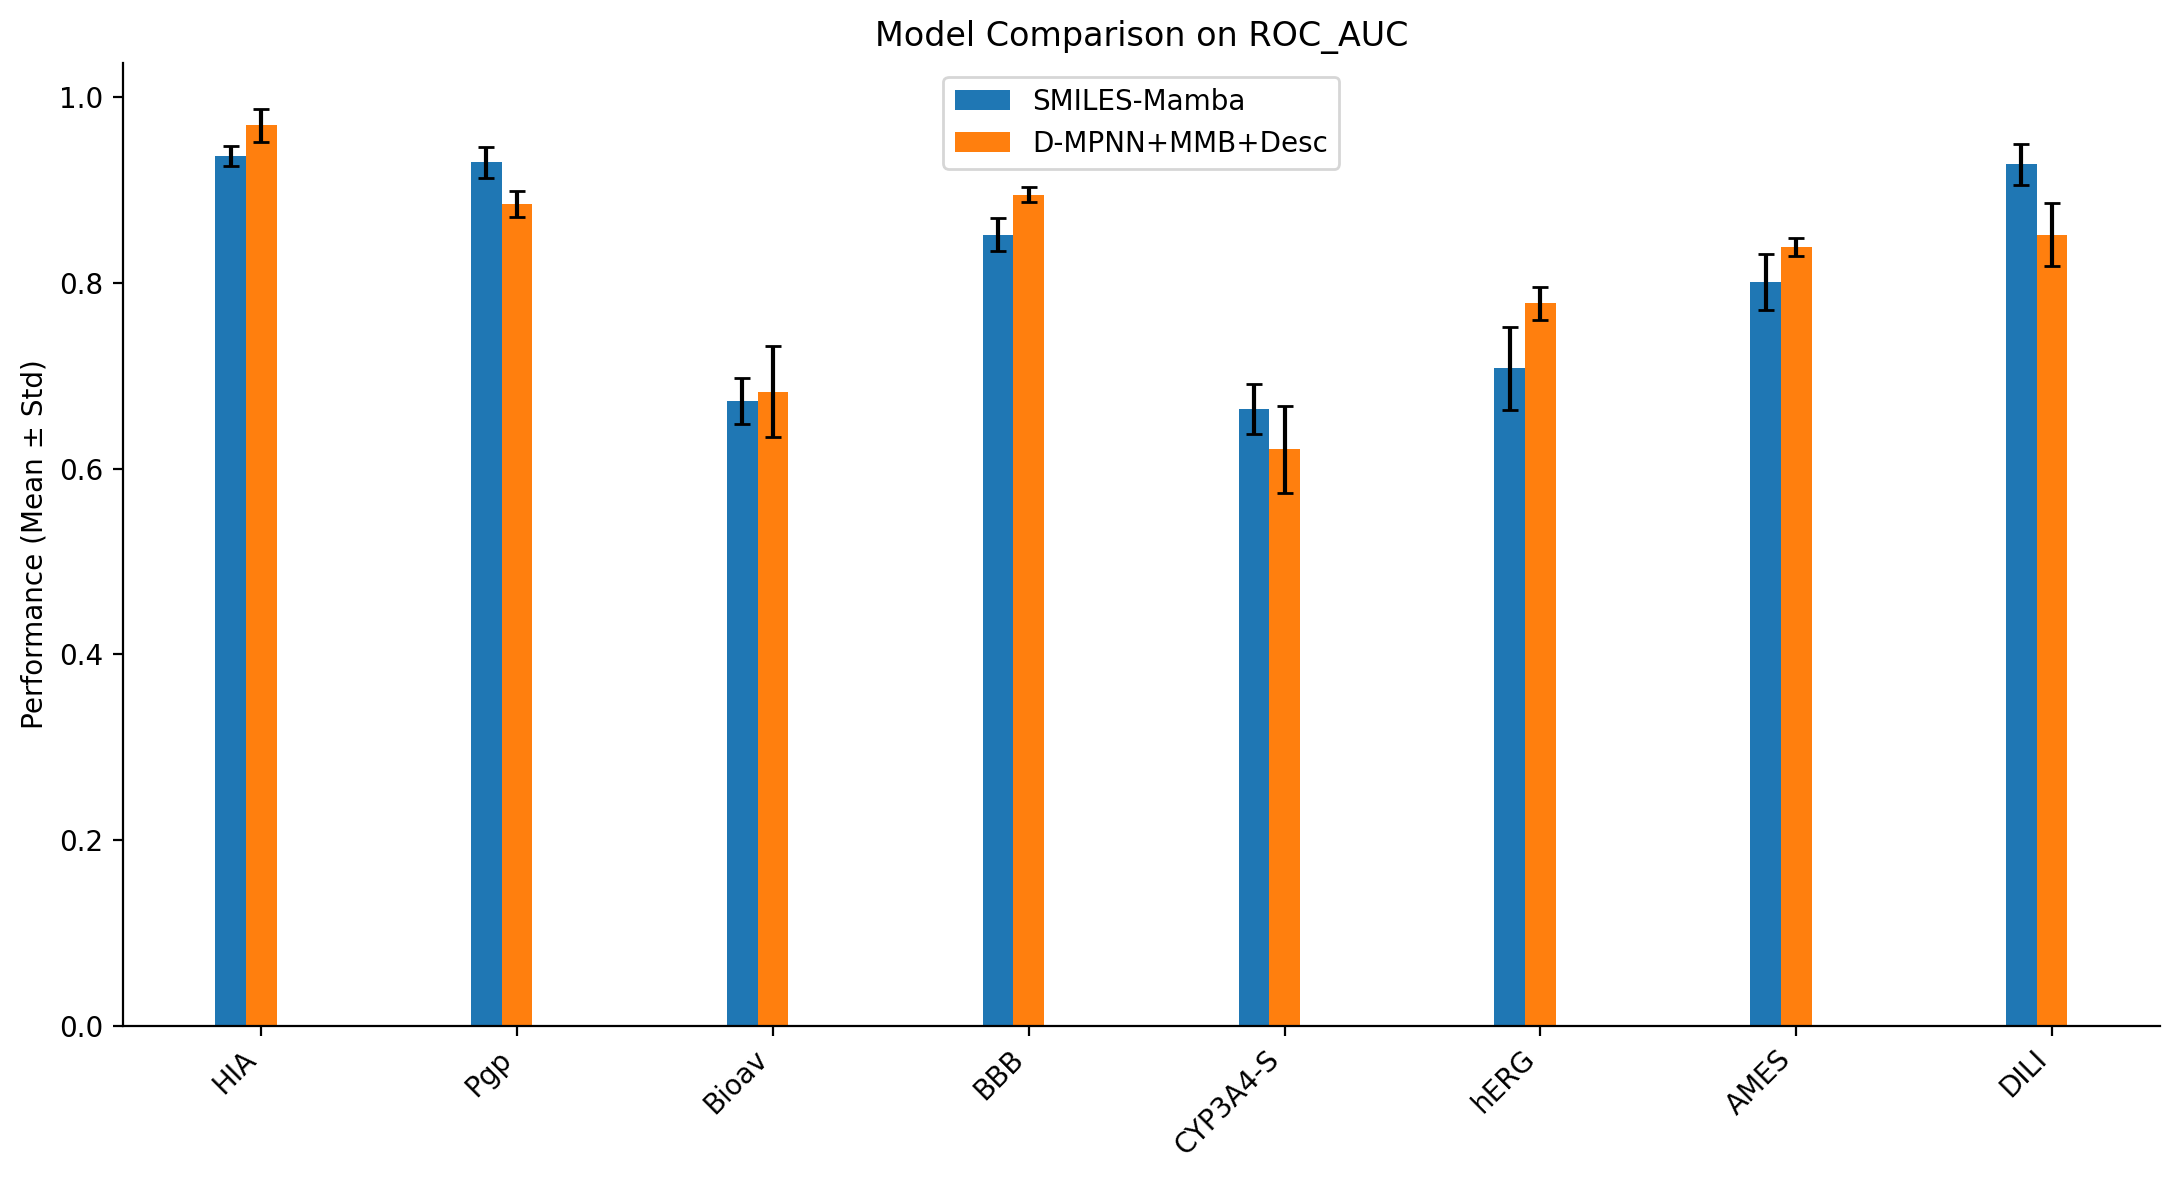

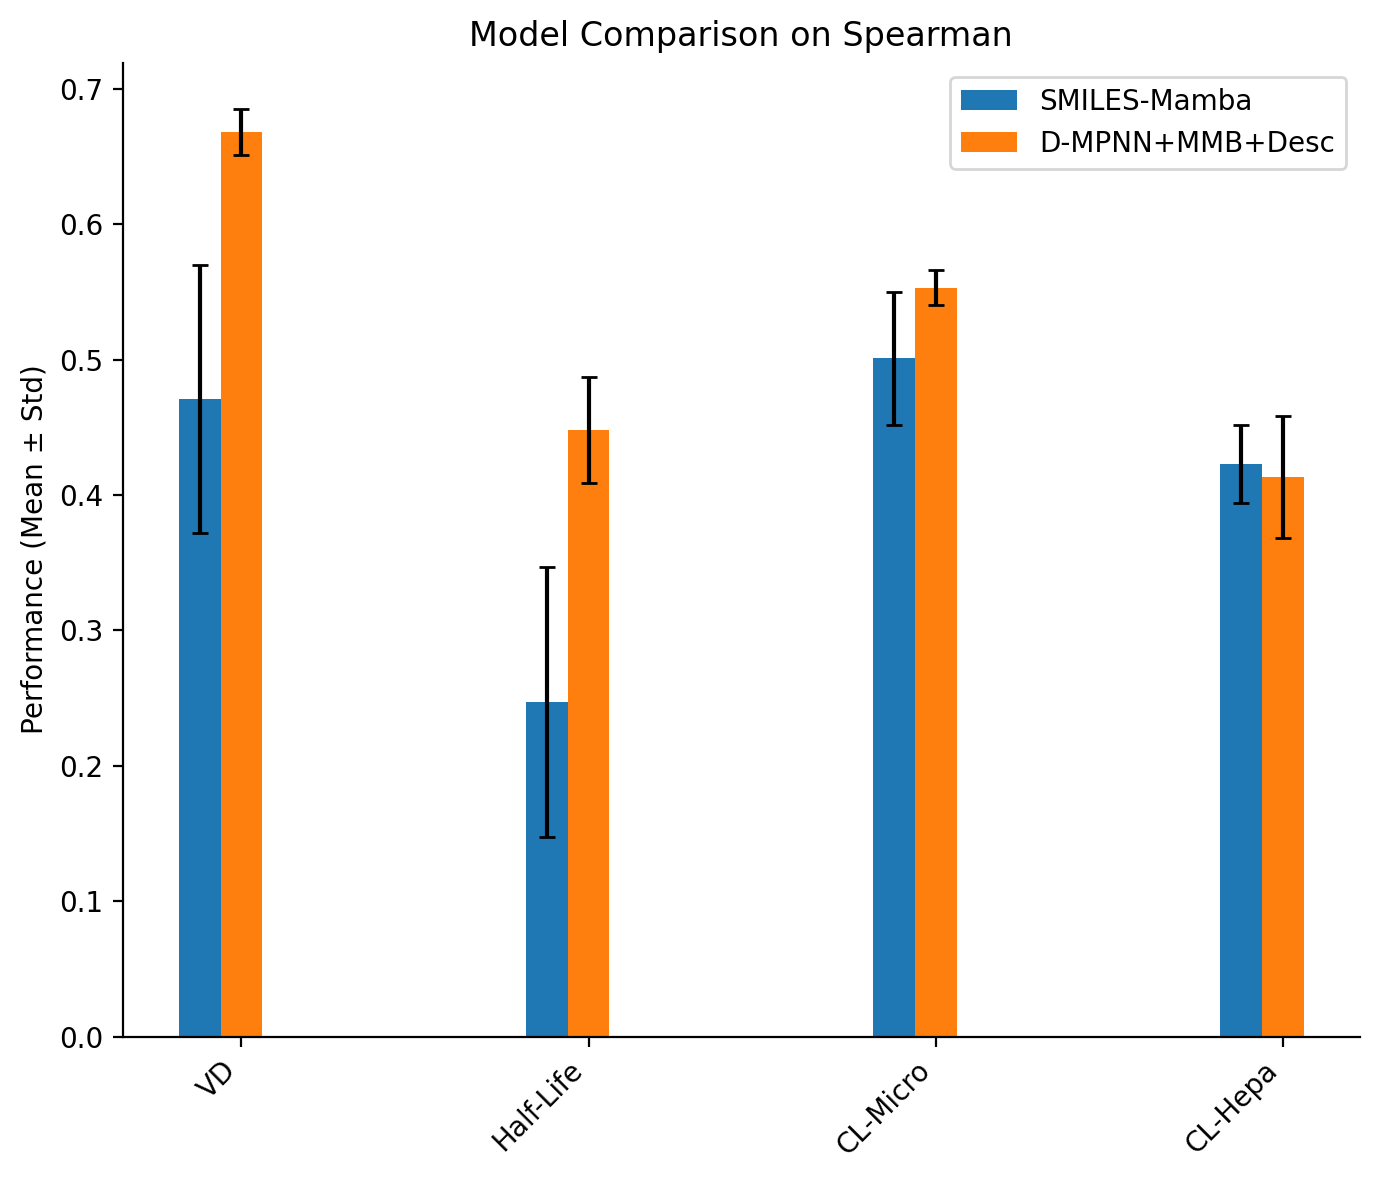

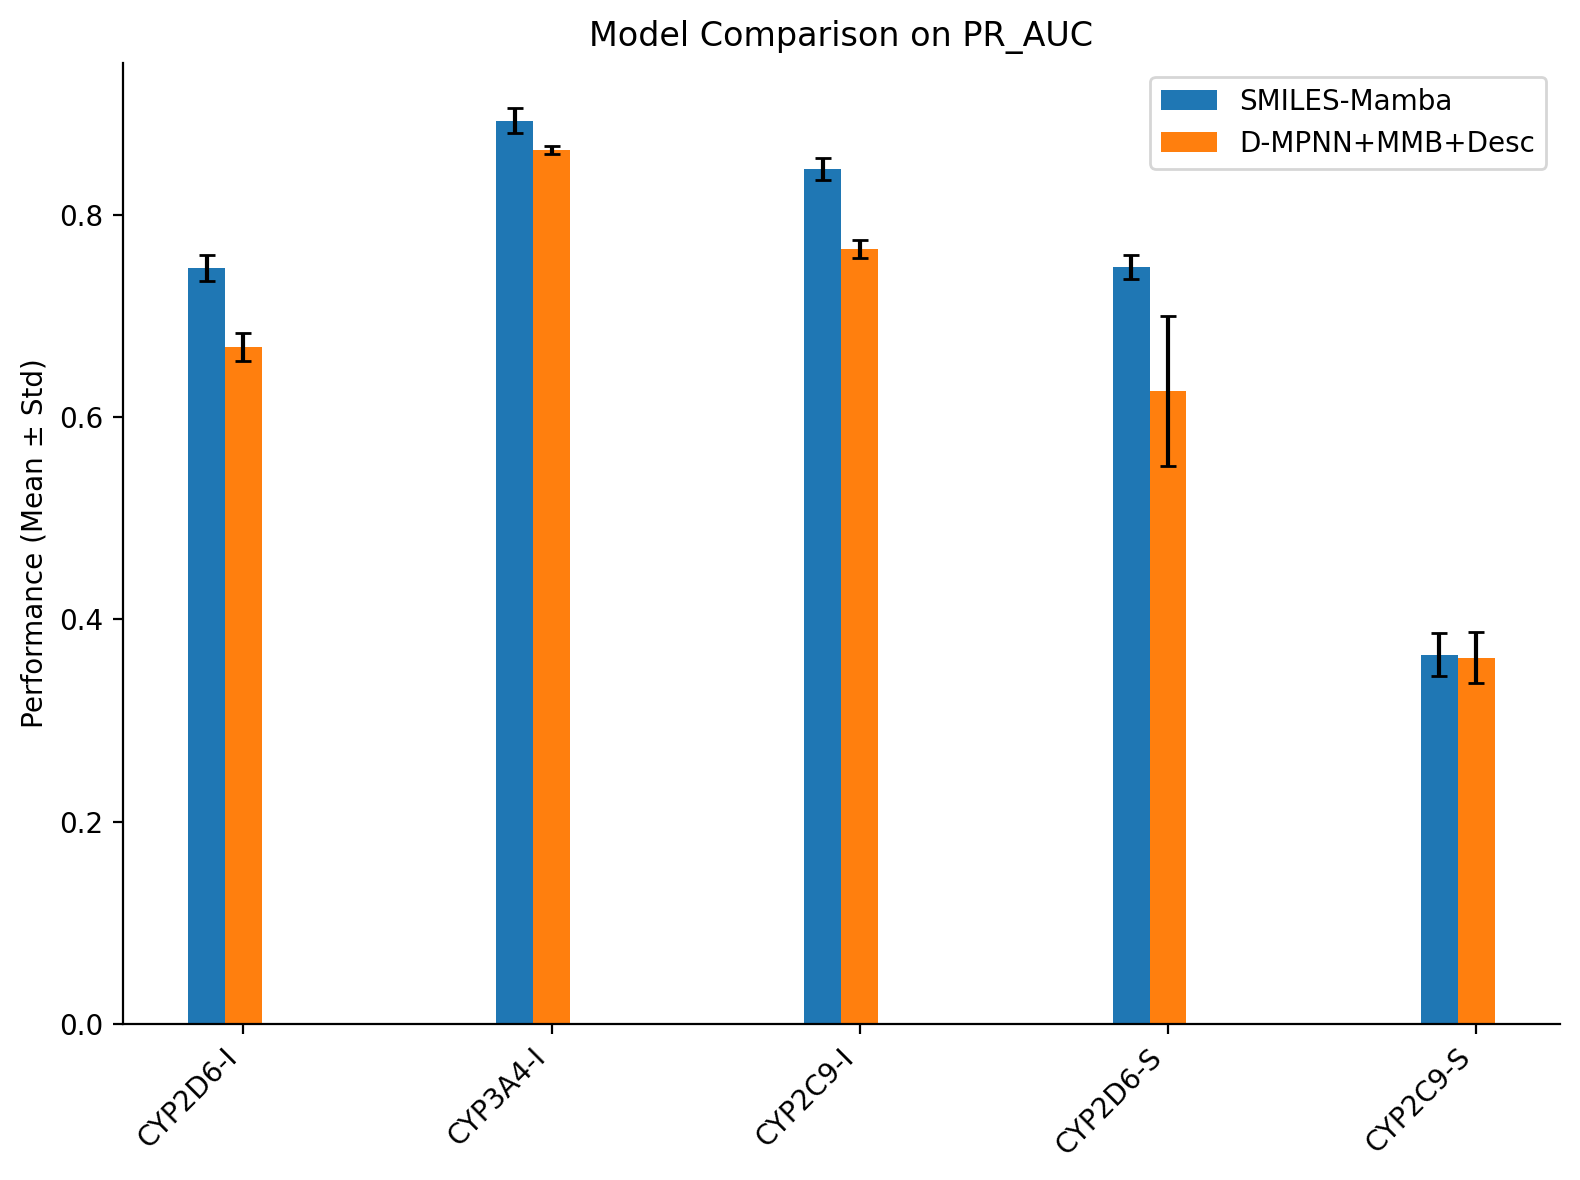

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

metrics = df_with_mamba['metric'].unique()

# models = df_with_mamba['model'].unique()
models = ["SMILES-Mamba", "D-MPNN+MMB+Desc"]

# palette = sns.color_palette("Set2", n_colors=len(models))
# palette = sns.color_palette("Paired", n_colors=len(models))
palette = sns.color_palette("tab10", n_colors=len(models))

for metric in metrics:
    metric_df = df_with_mamba[df_with_mamba['metric'] == metric]
    data_names = metric_df['data_name'].unique()
    x = np.arange(len(data_names))
    width = 0.12

    fig, ax = plt.subplots(figsize=(min(16, 3+len(data_names)), 6), dpi=200)
    for i, model in enumerate(models):
        model_df = metric_df[metric_df['model'] == model].set_index('data_name')
        y = model_df.reindex(data_names)['mean'].values
        yerr = model_df.reindex(data_names)['std'].values
        ax.bar(
            x + i*width,
            y,
            width,
            label=model,
            yerr=yerr,
            capsize=3,
            color=palette[i]
        )

    ax.set_xticks(x + width*len(models)/2)
    ax.set_xticklabels(data_names, rotation=45, ha='right')
    ax.set_ylabel('Performance (Mean ± Std)')
    ax.set_title(f"Model Comparison on {metric}")
    ax.legend()
    sns.despine() 
    plt.tight_layout()
    plt.show()
